In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import matplotlib.dates as mdates
import datetime

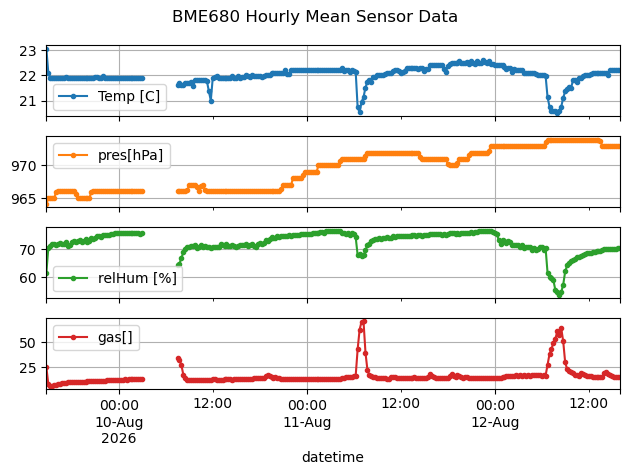

In [12]:
AVG = '15min'

fnames = [
    'sensor_data_2026-08-01_11_12_05.csv',
    'sensor_data_2026-08-01_12_49_16.csv',
    'sensor_data_2026-08-01_13_07_13.csv',
    'sensor_data_2026-08-09_14_57_20.csv',
    'sensor_data_2026-08-10_07_31_15.csv'
]

dfs = {}

for fname in fnames:
    csv_path = Path(f'../data/{fname}').resolve()
    df = pd.read_csv(csv_path)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.set_index('datetime')
    dfs[fname] = df

plot_df = pd.concat(
    [df.assign(source_file=fname) for fname, df in dfs.items()]
).sort_index()

# Filter to only include data starting from Aug-9
plot_df = plot_df[plot_df.index >= '2026-08-09']

# Filter pressure values below 100 hPa to NaN before averaging.
plot_df.loc[plot_df['pres[hPa]'] < 100, 'pres[hPa]'] = np.nan


plot_cols = ['Temp [C]', 'pres[hPa]', 'relHum [%]', 'gas[]']
hourly_df = plot_df[plot_cols].resample(AVG).mean()

axes = hourly_df.plot(
    y=plot_cols,
    subplots=True,
    layout=(4, 1),
    # figsize=(12, 8),
    grid=True,
    marker='.',
    title='BME680 Hourly Mean Sensor Data'
)


plt.tight_layout()
#plt.show()
now = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
fname_fig = f'BME680_sensor_data_{AVG}_{now}.png'
fig_out = Path(f'../out/{fname_fig}')
plt.savefig(fig_out, dpi=300)

In [17]:
plot_df[-5:]

,DEVICE_ID,seconds_since_start,Temp [C],pres[hPa],relHum [%],gas[],source_file
datetime,,,,,,,
2026-08-10 02:59:25.979715,Pico_Werkstatt_1,43157.0,21.9,966.0,75.4,13.0,sensor_data_2026-08-09_14_57_20.csv
2026-08-10 03:01:26.189980,Pico_Werkstatt_1,43277.0,21.9,966.0,75.0,13.0,sensor_data_2026-08-09_14_57_20.csv
2026-08-10 03:03:26.400252,Pico_Werkstatt_1,43398.0,21.9,966.0,75.4,13.0,sensor_data_2026-08-09_14_57_20.csv
2026-08-10 03:05:26.610236,Pico_Werkstatt_1,43518.0,21.9,966.0,75.4,13.0,sensor_data_2026-08-09_14_57_20.csv
2026-08-10 07:31:15.760631,Pico_Werkstatt_1,59467.0,21.7,966.0,64.8,53.1,sensor_data_2026-08-10_07_31_15.csv
